In [ ]:
import numpy as np
import csv
import matplotlib.pyplot as plt

# File reading:

This section contains the method to read the csv file d1 and print each row in it and save the first value of each row to the lmda list, which is plotted along x axis and corresponding B_val plotted along y axis.


In [ ]:
fle  = open("/content/d1.txt")

reader = csv.reader(fle)
lmda = []
B_val = []
for row in reader:
  print(row)
  lmda.append(float(row[0]))
  B_val.append(float(row[1]))

print("The values of t or lmda (wavelength) :", lmda)
print("The corr. values of B are: ",B_val)






['1.0000000000000001e-07', '-218873350261.91592']
['1.4949494949494952e-07', '27303084401.037075']
['1.98989898989899e-07', '-102183523091.05168']
['2.484848484848485e-07', '-4255539572.130745']
['2.9797979797979803e-07', '515843448218.6518']
['3.474747474747475e-07', '804608379615.4872']
['3.9696969696969697e-07', '1400534948068.665']
['4.4646464646464655e-07', '2115816194870.5598']
['4.959595959595961e-07', '3238864696769.648']
['5.454545454545455e-07', '3342682923605.807']
['5.94949494949495e-07', '3900504563586.5444']
['6.444444444444445e-07', '4237517251124.779']
['6.93939393939394e-07', '4495219170310.889']
['7.434343434343435e-07', '4213678006896.0522']
['7.92929292929293e-07', '3984946385724.1626']
['8.424242424242425e-07', '3965185371091.039']
['8.91919191919192e-07', '3635827616645.2173']
['9.414141414141415e-07', '3848482613942.521']
['9.909090909090909e-07', '3760019603233.2646']
['1.0404040404040407e-06', '3504434949211.088']
['1.0898989898989901e-06', '2642856304121.75']


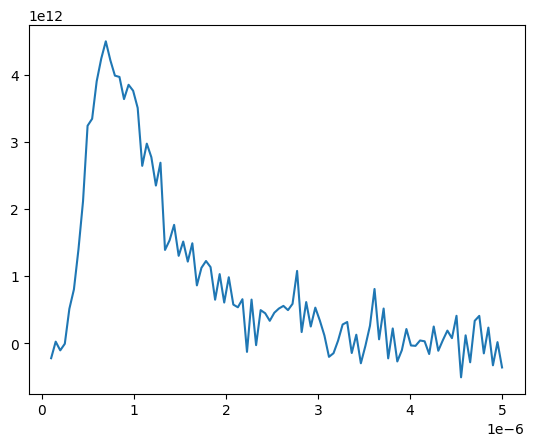

In [ ]:
plt.plot(lmda, B_val)   # plotting

# CURVE FITTING:

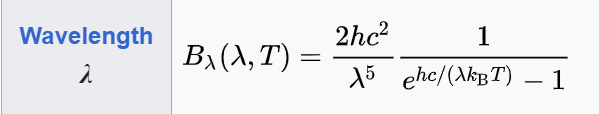

Here, I define the fucntion B and curve fit it onto the data d1 and estimate all 4 parameters : h, c, k, T. Then compare the plot between actual data and curve that was fitted

In [ ]:
def B(p,h,c,k,T):
  ans = (2*h*c**2)/(p**5*(np.exp(h*c/(p*k*T))-1))   # Defining the fucntion as the formula
  return ans

Below is an example to show how important the initial guesses are, they are very important.
Also if we don't initialise the paramters accurately, it shows inf as it doesnt converge ebcause the actual value of paramters are at extremes

In [ ]:
p_opt, p_cov = scipy.optimize.curve_fit(B, lmda, B_val, p0 = [1, 1, 1, 1])
p_opt

<ipython-input-8-4ae8c43c8966>:2: RuntimeWarning: overflow encountered in exp
  ans = (2*h*c**2)/(p**5*(np.exp(h*c/(p*k*T))-1))
<ipython-input-21-50cadaad4456>:1: OptimizeWarning: Covariance of the parameters could not be estimated
  p_opt, p_cov = scipy.optimize.curve_fit(B, lmda, B_val, p0 = [1, 1, 1, 1]) #if we don't initialise the paramters accurately, it shows inf as it doesnt converge ebcause the paramters are at extremes


array([1., 1., 1., 1.])

In [ ]:
import scipy
scipy.optimize.curve_fit(B, lmda, B_val, p0 = [6.626e-34, 3e8, 1.38e-23, 3000])  #testing it out


(array([5.53803408e-34, 3.23497107e+08, 1.35836318e-23, 3.70508991e+03]),
 array([[ 9.45836138e-56, -2.76248934e-14,  2.39318397e-46,
          2.51117785e-19],
        [-2.76248934e-14,  8.06836097e+27, -6.98973645e-05,
         -7.33435923e+22],
        [ 2.39318397e-46, -6.98973645e-05,  8.87393459e-35,
         -2.34041136e-08],
        [ 2.51117785e-19, -7.33435923e+22, -2.34041136e-08,
          7.22375989e+18]]))

In [ ]:
p_opt, p_cov = scipy.optimize.curve_fit(B, lmda, B_val, p0 = [6.626e-34, 3e8, 1.38e-23, 3000]) #Initialising with actual values to get a better understanding of the range of the paramters
p_opt

array([5.53803408e-34, 3.23497107e+08, 1.35836318e-23, 3.70508991e+03])

We can see that the values aren't that accurate. These are the actual values : 6.626e-34, 3e8, 1.38e-23

In [ ]:
[h_opt, c_opt, k_opt,T_opt] = p_opt  # unpacking the list

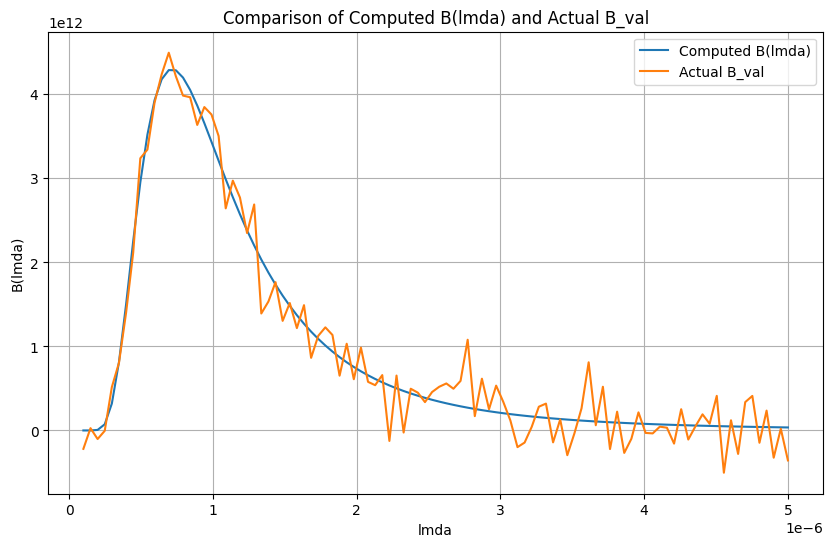

In [ ]:
computed_B = [B(p, h_opt, c_opt, k_opt, T_opt) for p in lmda]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(lmda, computed_B, label='Computed B(lmda)')
plt.plot(lmda, B_val, label='Actual B_val')
plt.xlabel('lmda')
plt.ylabel('B(lmda)')
plt.title('Comparison of Computed B(lmda) and Actual B_val')
plt.grid(True)
plt.legend()
plt.show()

# USING PARTIAL FUNCTIONS:

In this section, I define partial functions to estimate the respective parameter taking known values of the rest, this is done to get a more accurate estimates of the parameters

In [ ]:
def B_T(t, T):
  h_f = 6.62607015e-34
  c_f = 2.99792458e+08
  k_f = 1.380649e-23
  return B(t, h_f, c_f, k_f, T)

In [ ]:
p_opt, p_cov = scipy.optimize.curve_fit(B_T, lmda, B_val, p0 = [3000])
[T_opt] = p_opt
print(T_opt)

4019.794168029399


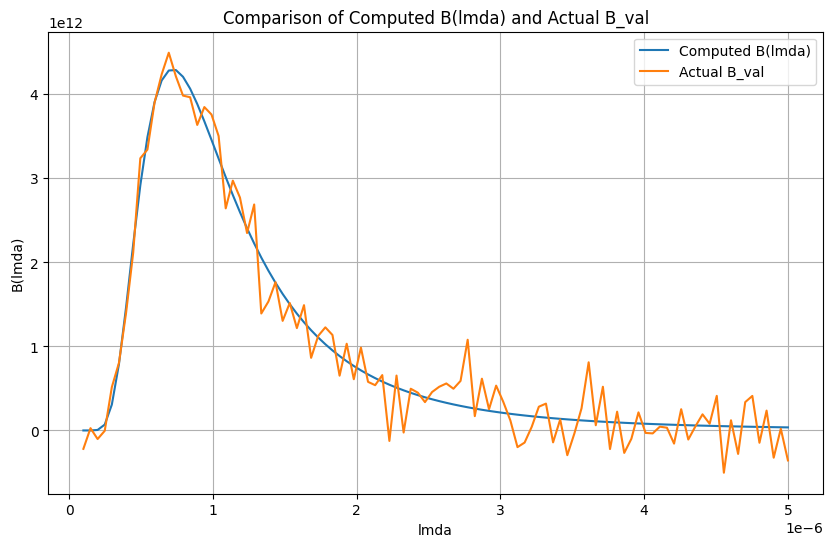

In [ ]:
computed_B_T = [B_T(t, T_opt) for t in lmda]   # list of all computed values of B_T for various lmda

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(lmda, computed_B_T, label='Computed B(lmda)')
plt.plot(lmda, B_val, label='Actual B_val')
plt.xlabel('lmda')
plt.ylabel('B(lmda)')
plt.title('Comparison of Computed B(lmda) and Actual B_val')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def B_h(t,h):
  c_f = 2.99792458e+08
  k_f = 1.380649e-23
  T_f = 4019.794168029399
  return B(t, h, c_f, k_f, T_f)

In [ ]:
p_opt, p_cov = scipy.optimize.curve_fit(B_h, lmda, B_val, p0 = [1e-34])
[h_opt] = p_opt
print(h_opt)

6.624888287491846e-34


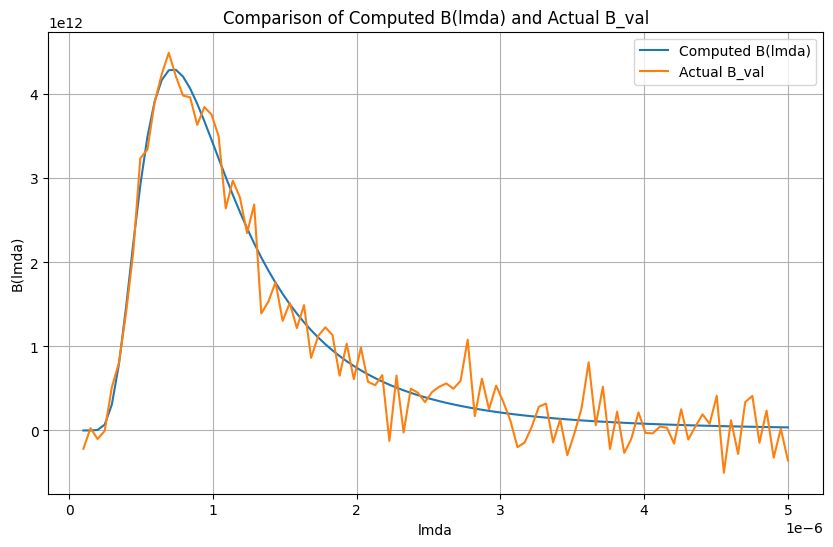

In [ ]:
computed_B_h = [B_h(t, h_opt) for t in lmda]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(lmda, computed_B_h, label='Computed B(lmda)')
plt.plot(lmda, B_val, label='Actual B_val')
plt.xlabel('lmda')
plt.ylabel('B(lmda)')
plt.title('Comparison of Computed B(lmda) and Actual B_val')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def B_c(t, c):
  h_f = 6.62607015e-34
  T_f = 4019.794168029399
  k_f = 1.380649e-23
  return B(t, h_f, c, k_f, T_f)

In [ ]:
p_opt, p_cov = scipy.optimize.curve_fit(B_c, lmda, B_val, p0 = [1e8])
[c_opt] = p_opt
print(c_opt)

299608659.3335721


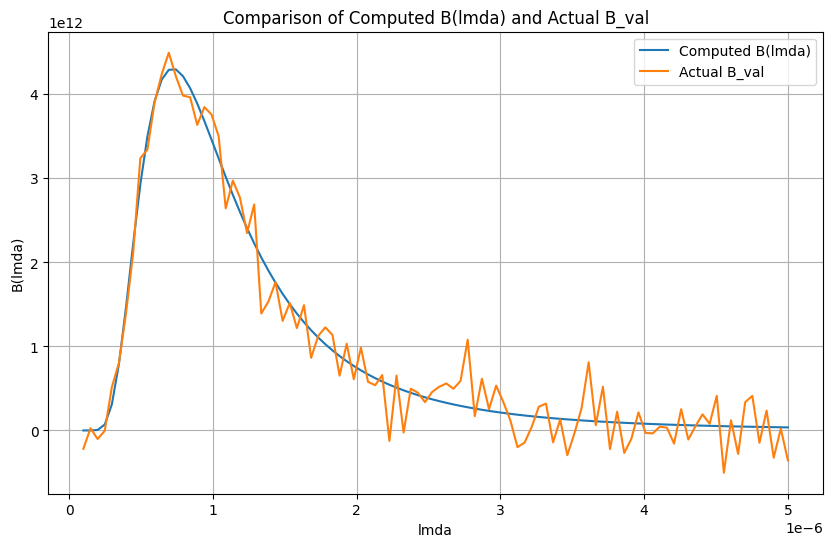

In [ ]:
computed_B_c = [B_c(t, c_opt) for t in lmda]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(lmda, computed_B_c, label='Computed B(lmda)')
plt.plot(lmda, B_val, label='Actual B_val')
plt.xlabel('lmda')
plt.ylabel('B(lmda)')
plt.title('Comparison of Computed B(lmda) and Actual B_val')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def B_k(t, k):
  h_f = 6.62607015e-34
  T_f = 4019.794168029399
  c_f = 2.99792458e+08
  return B(t, h_f, c_f, k, T_f)

In [ ]:
p_opt, p_cov = scipy.optimize.curve_fit(B_k, lmda, B_val, p0 = [1.38e-23])
[k_opt] = p_opt
print(k_opt)

1.3806489975211573e-23


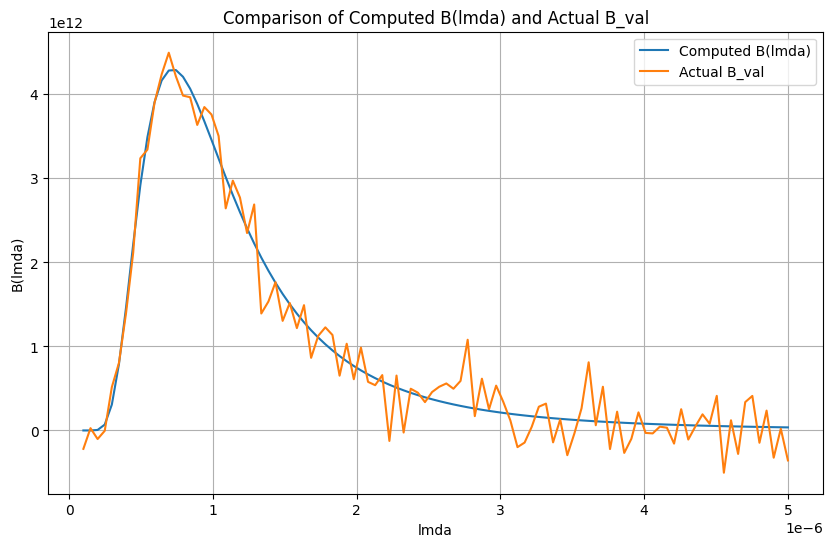

In [ ]:
computed_B_k = [B_k(t, k_opt) for t in lmda]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(lmda, computed_B_k, label='Computed B(lmda)')
plt.plot(lmda, B_val, label='Actual B_val')
plt.xlabel('lmda')
plt.ylabel('B(lmda)')
plt.title('Comparison of Computed B(lmda) and Actual B_val')
plt.grid(True)
plt.legend()
plt.show()

# Defining common functions

As I have to repeat the same above procedure on 3 more csv files, I might as well create functions:
Going through the steps:
1. Read the csv file, get the x-axis/lmda values and y-axis/ B_val and plot the curve.
2. For Curve fitting the function B AND estimating all 4 parameters from that and plotting it.
3. for curve fitting partial functions, estimating unknown paramter anf plotting them.

Creating functions for the last two steps:



**The comparision plotter** - Plots the Actual data from the file and then the Curve fit on this data. It takes in the paramters lmda, B_val, computed_B (Curve fit plot), transparency_true = 1, transparency_comp= 1,line_width = 1. (The last three are for making the curves and plots more visible and neat)

In [ ]:

def comparision_plotter(lmda, B_val, computed_B, transparency_true = 1, transparency_comp= 1,line_width = 1) :
  plt.figure(figsize=(10, 6))
  plt.plot(lmda, B_val, label='Actual B_val', alpha = transparency_comp, color = 'orange')
  plt.plot(lmda, computed_B, label='Computed B(lmda)', alpha =  transparency_true, color = "blue" )
  plt.xlabel('lmda')
  plt.ylabel('B(lmda)')
  plt.title('Comparison of Computed B(lmda) and Actual B_val')
  plt.grid(True)
  plt.legend()
  plt.show()



**The estimate_all_parameters** - This function is used to curve fit B and estimate all 4 parameters and plot it along with actual plot using comparision plotter.
Takes in actual x and y values,and the initial guesses for all 4 parameters.

In [ ]:
def estimate_all_parameters(lmda, B_val, initial_guess = [6.626e-34, 3e8, 1.38e-23, 3000], transparency_comp= 1 ):
  def B(p,h,c,k,T):
    ans = (2*h*c**2)/(p**5*(np.exp(h*c/(p*k*T))-1))
    return ans

  p_opt, p_cov = scipy.optimize.curve_fit(B, lmda, B_val, p0 = initial_guess )
  [h_opt, c_opt, k_opt,T_opt] = p_opt
  print("Optimal values: hopt:", h_opt ,", c_opt :", c_opt , ",k_opt:", k_opt, ",T_opt:", T_opt)
  computed_B = [B(p, h_opt, c_opt, k_opt, T_opt) for p in lmda]
  comparision_plotter(lmda, B_val, computed_B, transparency_comp = transparency_comp)



**The estimating_T** - This function is used to find optimal value of T by curve fitting data with B but every other paramter in B is taking its already defined fixed value. Hence I call this function B_T and of course, plot it along with actual plot using comparision plotter.
Takes in actual x and y values,and the initial guesses for all 4 parameters.

In [ ]:
def estimating_T(lmda, B_val, initial_guess = 3000, plot = True, transparency_comp= 1 ):
  def B_T(t, T):
    h_f = 6.62607015e-34                #_f means fixed
    c_f = 2.99792458e+08
    k_f = 1.380649e-23
    return B(t, h_f, c_f, k_f, T)
  p_opt, p_cov = scipy.optimize.curve_fit(B_T, lmda, B_val, p0 = [initial_guess])
  [T_opt] = p_opt
  computed_B_T = [B_T(t, T_opt) for t in lmda]
  if plot == True:
    print("Optimal value of T, when using partial function is ", T_opt)
    comparision_plotter(lmda, B_val, computed_B_T, transparency_comp = transparency_comp)        # this is done to segregate the cases in which we'd want to use the T estimated and not plot or print the value
  return T_opt


Similarly we define other functions however for the value of T_f we use the previously estimated value as it will lead to more accurate results.

In [ ]:
def estimating_h(lmda, B_val, initial_guess = 1e-34,transparency_comp= 1) :
  def B_h(t,h):
    c_f = 2.99792458e+08
    k_f = 1.380649e-23
    T_f = estimating_T(lmda, B_val, initial_guess = 3000, plot = False)   # Using the estimated value of T
    return B(t, h, c_f, k_f, T_f)
  p_opt, p_cov = scipy.optimize.curve_fit(B_h, lmda, B_val, p0 = [1e-34])
  [h_opt] = p_opt
  print("Optimal value of h, when using partial function is ", h_opt)
  computed_B_h = [B_h(t, h_opt) for t in lmda]
  comparision_plotter(lmda, B_val, computed_B_h, transparency_comp = transparency_comp)

In [ ]:
def estimating_c(lmda, B_val, initial_guess = 1e8, transparency_comp= 1 ):
  def B_c(t, c):
    h_f = 6.62607015e-34
    T_f = estimating_T(lmda, B_val, initial_guess = 3000, plot = False)
    k_f = 1.380649e-23
    return B(t, h_f, c, k_f, T_f)
  p_opt, p_cov = scipy.optimize.curve_fit(B_c, lmda, B_val, p0 = [initial_guess])
  [c_opt] = p_opt
  print("Optimal value of c, when using partial function is ", c_opt)
  computed_B_c = [B_c(t, c_opt) for t in lmda]
  comparision_plotter(lmda, B_val, computed_B_c, transparency_comp = transparency_comp)

In [ ]:
def estimating_k(lmda, B_val, initial_guess = 1.38e-23,transparency_comp= 1 ):
  def B_k(t, k):
    h_f = 6.62607015e-34
    T_f = estimating_T(lmda, B_val, initial_guess = 3000, plot = False)
    c_f = 2.99792458e+08
    return B(t, h_f, c_f, k, T_f)
  p_opt, p_cov = scipy.optimize.curve_fit(B_k, lmda, B_val, p0 = [1.38e-23])
  [k_opt] = p_opt
  print("Optimal value of k, when using partial function is ", k_opt)
  computed_B_k = [B_k(t, k_opt) for t in lmda]
  comparision_plotter(lmda, B_val, computed_B_k, transparency_comp = transparency_comp)

# Testing these functions on the csv files

We can use only this section here after once we run the define fucntion cells


## Checking d1:

In [ ]:
fle  = open("/content/d1.txt")

reader = csv.reader(fle)
lmda = []
B_val = []
for row in reader:
  print(row)
  lmda.append(float(row[0]))
  B_val.append(float(row[1]))

print("The values of t or lmda (wavelength) :", lmda)
print("The corr. values of B are: ",B_val)


['1.0000000000000001e-07', '-218873350261.91592']
['1.4949494949494952e-07', '27303084401.037075']
['1.98989898989899e-07', '-102183523091.05168']
['2.484848484848485e-07', '-4255539572.130745']
['2.9797979797979803e-07', '515843448218.6518']
['3.474747474747475e-07', '804608379615.4872']
['3.9696969696969697e-07', '1400534948068.665']
['4.4646464646464655e-07', '2115816194870.5598']
['4.959595959595961e-07', '3238864696769.648']
['5.454545454545455e-07', '3342682923605.807']
['5.94949494949495e-07', '3900504563586.5444']
['6.444444444444445e-07', '4237517251124.779']
['6.93939393939394e-07', '4495219170310.889']
['7.434343434343435e-07', '4213678006896.0522']
['7.92929292929293e-07', '3984946385724.1626']
['8.424242424242425e-07', '3965185371091.039']
['8.91919191919192e-07', '3635827616645.2173']
['9.414141414141415e-07', '3848482613942.521']
['9.909090909090909e-07', '3760019603233.2646']
['1.0404040404040407e-06', '3504434949211.088']
['1.0898989898989901e-06', '2642856304121.75']


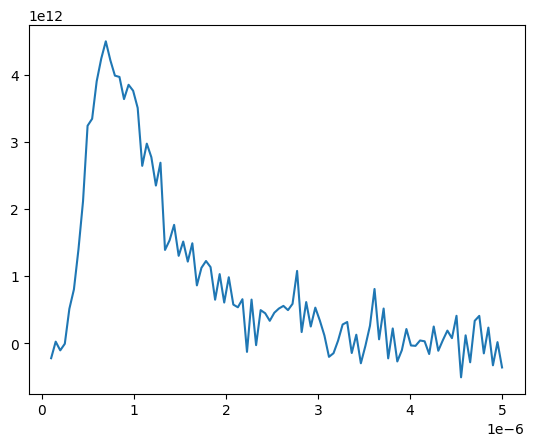

In [ ]:
plt.plot(lmda, B_val)

Optimal values: hopt: 5.538034076202609e-34 , c_opt : 323497106.566632 ,k_opt: 1.358363176495288e-23 ,T_opt: 3705.089914732919


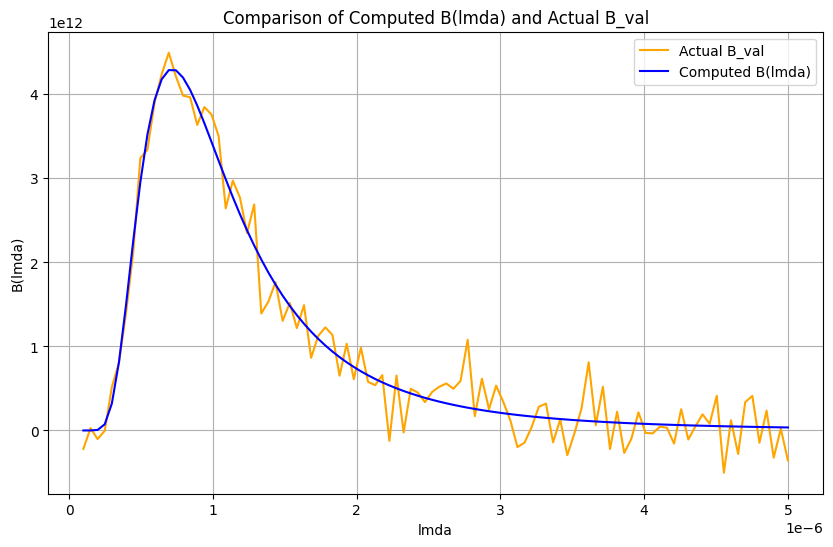



Optimal value of T, when using partial function is  4019.794168029399


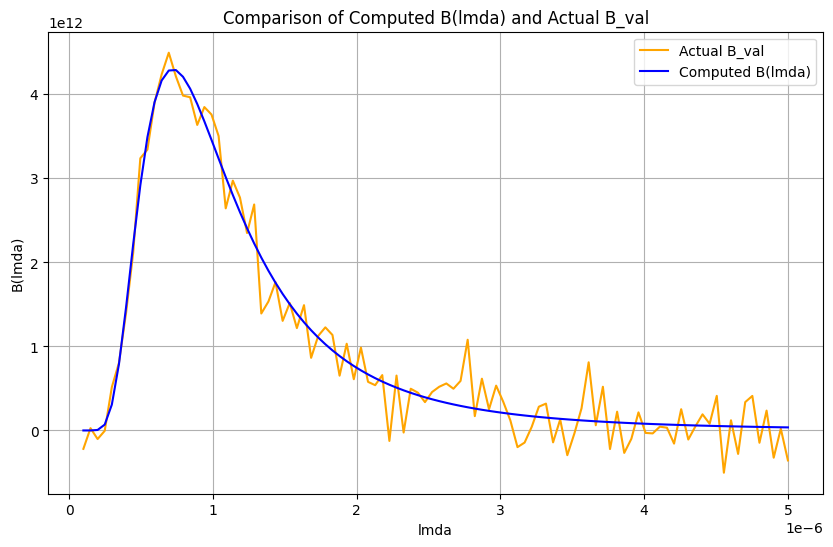



Optimal value of h, when using partial function is  6.624888287491846e-34


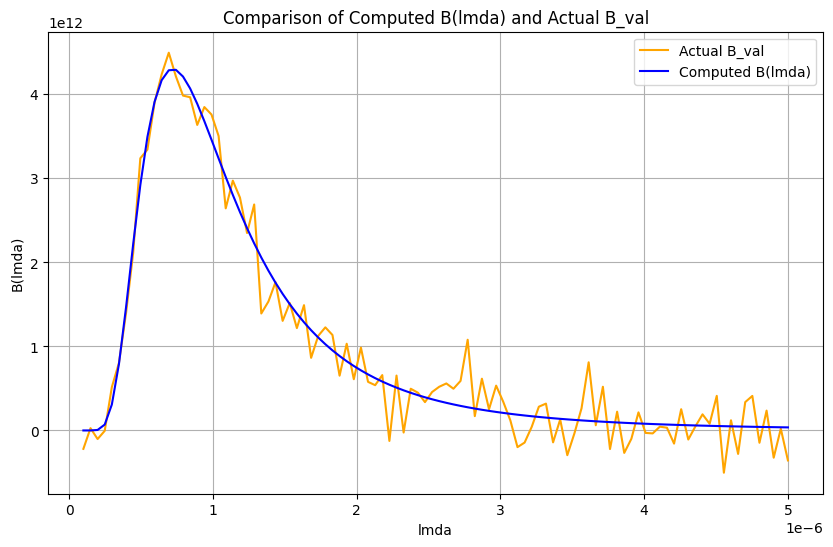



Optimal value of c, when using partial function is  299608659.3335721


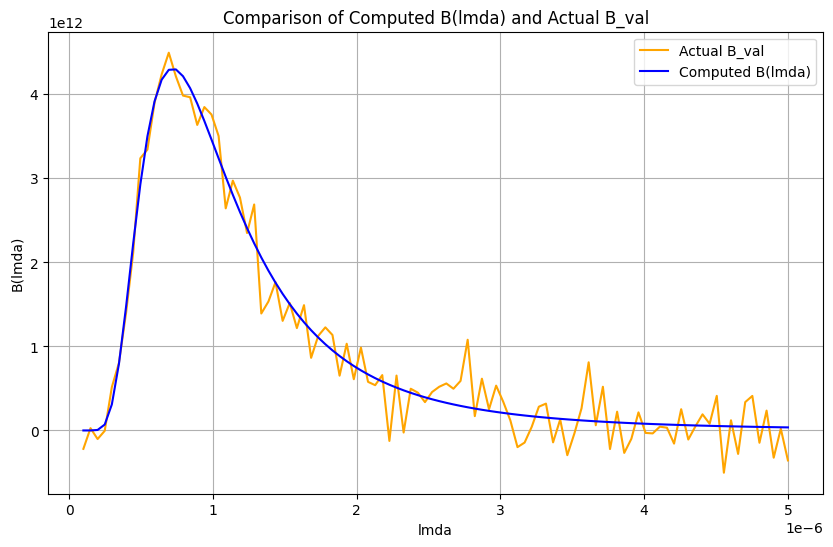



Optimal value of k, when using partial function is  1.3806489975211573e-23


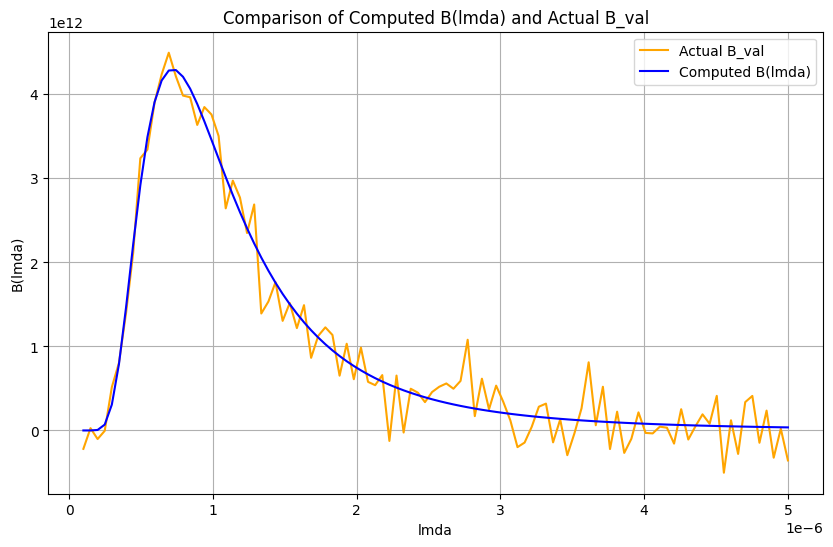

In [ ]:
estimate_all_parameters(lmda, B_val, initial_guess = [6.626e-34, 3e8, 1.38e-23, 3000])
print("\n")
estimating_T(lmda, B_val, initial_guess = 3000)
print("\n")
estimating_h(lmda, B_val, initial_guess = 1e-34)
print("\n")
estimating_c(lmda, B_val, initial_guess = 1e8)
print("\n")
estimating_k(lmda, B_val, initial_guess = 1.38e-23)

So the functions work fine and the same values


## For d2:

In [ ]:
fle  = open("/content/d2.txt")

reader = csv.reader(fle)
lmda = []
B_val = []
for row in reader:
  print(row)
  lmda.append(float(row[0]))
  B_val.append(float(row[1]))

print("The values of t or lmda (wavelength) :", lmda)
print("The corr. values of B are: ",B_val)



['1.0000000000000001e-07', '-3841961895785.864']
['1.4949494949494952e-07', '-5275665894136.208']
['1.98989898989899e-07', '244081213495.83398']
['2.484848484848485e-07', '-4973607456107.965']
['2.9797979797979803e-07', '-1223123709029.8542']
['3.474747474747475e-07', '-104226060543.70471']
['3.9696969696969697e-07', '1240880614501.5754']
['4.4646464646464655e-07', '-3172171647628.1084']
['4.959595959595961e-07', '7216423149241.955']
['5.454545454545455e-07', '-399411126953.02344']
['5.94949494949495e-07', '8189288174548.082']
['6.444444444444445e-07', '7833083958845.436']
['6.93939393939394e-07', '2299333704723.272']
['7.434343434343435e-07', '3538672027030.533']
['7.92929292929293e-07', '3790436875341.095']
['8.424242424242425e-07', '5230898905928.076']
['8.91919191919192e-07', '6303419539248.8125']
['9.414141414141415e-07', '1843779025505.46']
['9.909090909090909e-07', '1148517066521.982']
['1.0404040404040407e-06', '1995629692866.1575']
['1.0898989898989901e-06', '4154734320214.493

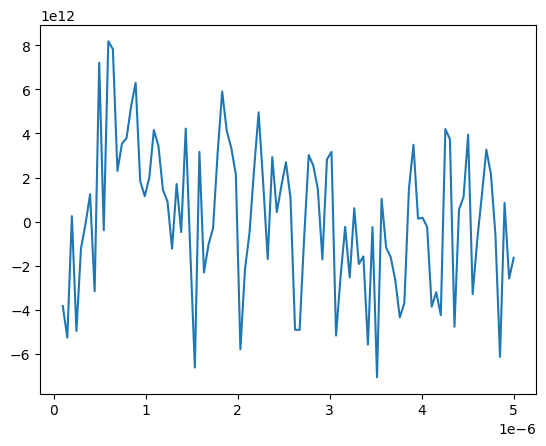

In [ ]:
plt.plot(lmda, B_val)

Optimal values: hopt: 5.2846642591983745e-34 , c_opt : 269965996.23129475 ,k_opt: 1.3546833439780036e-23 ,T_opt: 3155.02565289671


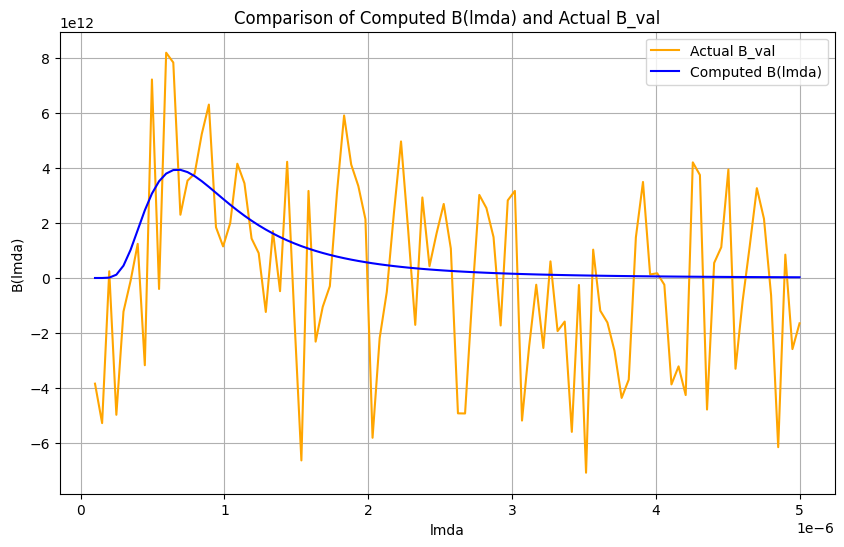



Optimal value of T, when using partial function is  3956.6918170717595


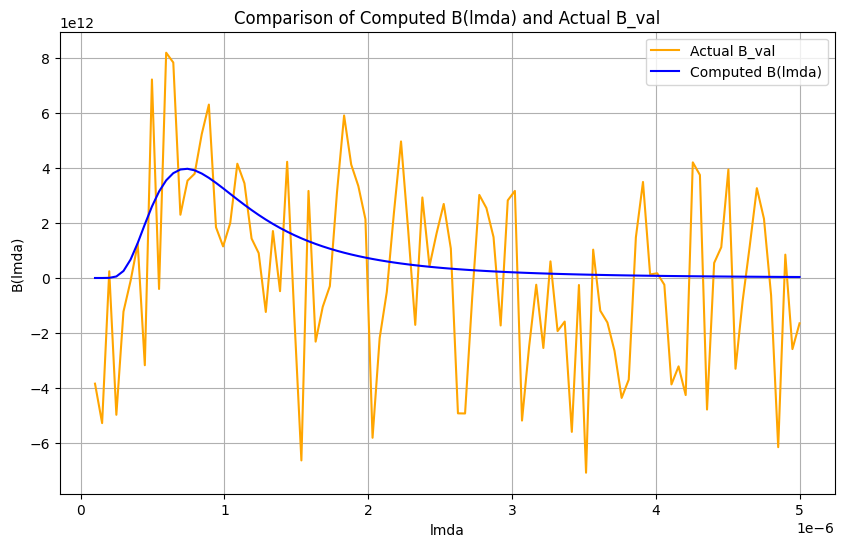



Optimal value of h, when using partial function is  6.598213963374519e-34


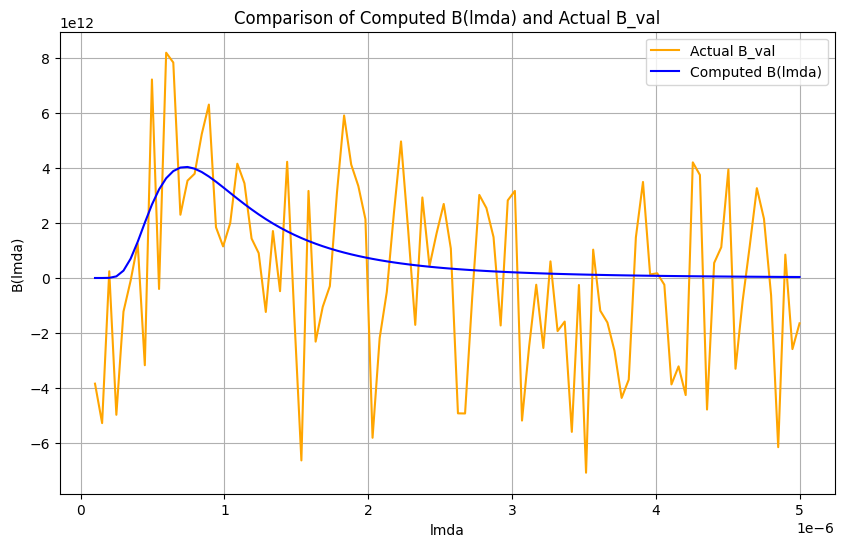



Optimal value of c, when using partial function is  295682850.6678101


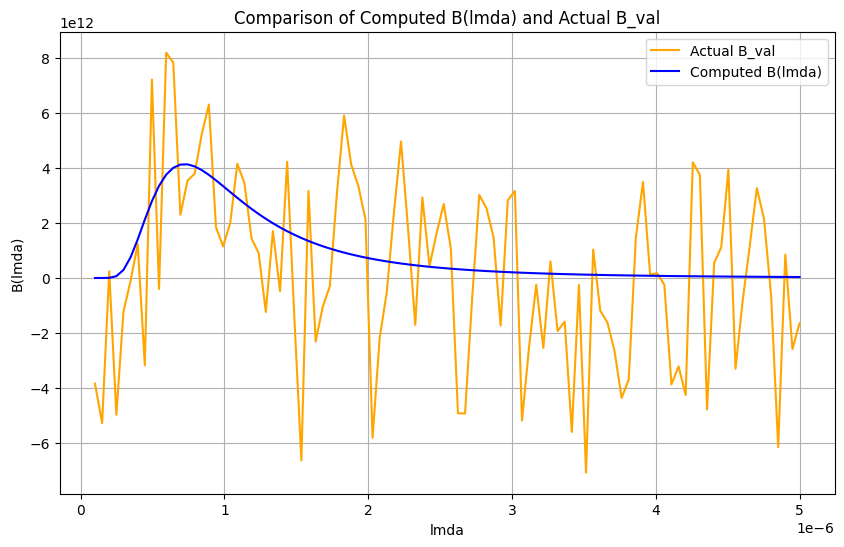



Optimal value of k, when using partial function is  1.3806489200863027e-23


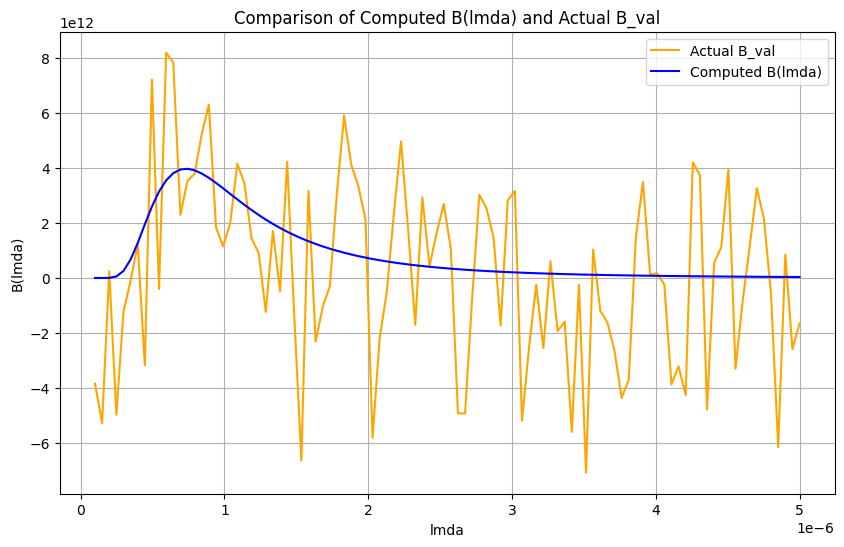

In [ ]:
estimate_all_parameters(lmda, B_val, initial_guess = [6.626e-34, 3e8, 1.38e-23, 3000])
print("\n")
estimating_T(lmda, B_val, initial_guess = 3000)
print("\n")
estimating_h(lmda, B_val, initial_guess = 1e-34)
print("\n")
estimating_c(lmda, B_val, initial_guess = 1e8)
print("\n")
estimating_k(lmda, B_val, initial_guess = 1.38e-23)

## For d3:

In [ ]:
fle  = open("/content/d3.txt")

reader = csv.reader(fle)
lmda = []
B_val = []
for row in reader:
  print(row)
  lmda.append(float(row[0]))
  B_val.append(float(row[1]))

print("The values of t or lmda (wavelength) :", lmda)
print("The corr. values of B are: ",B_val)



['1.0000000000000001e-07', '-359423290559.28906']
['1.049049049049049e-07', '-720013617524.2463']
['1.0980980980980982e-07', '299200014532.1846']
['1.1471471471471473e-07', '-227632677641.1721']
['1.1961961961961964e-07', '-591078230973.9143']
['1.2452452452452452e-07', '-58928913601.84836']
['1.2942942942942943e-07', '-216296286873.06662']
['1.3433433433433434e-07', '-410448472990.6666']
['1.3923923923923926e-07', '-133139214159.15837']
['1.4414414414414414e-07', '-23354747418.30523']
['1.4904904904904905e-07', '273981770326.6666']
['1.5395395395395396e-07', '-121046768068.54424']
['1.5885885885885887e-07', '169407509277.8464']
['1.6376376376376378e-07', '-136240767338.08455']
['1.686686686686687e-07', '521726211347.5967']
['1.7357357357357358e-07', '328384298180.9233']
['1.784784784784785e-07', '-222449357864.5131']
['1.833833833833834e-07', '-45424204695.65842']
['1.882882882882883e-07', '-120740622667.53911']
['1.9319319319319322e-07', '430702565760.5295']
['1.980980980980981e-07',

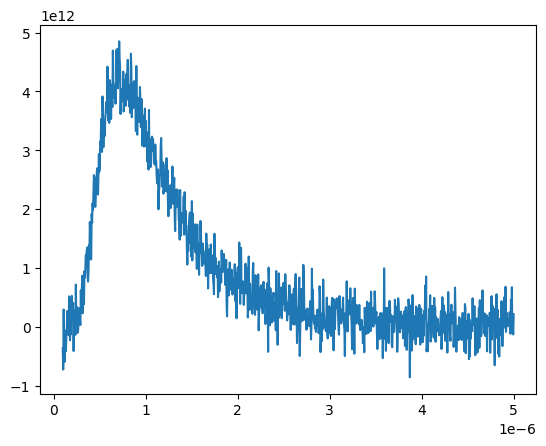

In [ ]:
plt.plot(lmda, B_val)

Optimal values: hopt: 7.417390136956695e-34 , c_opt : 276033715.3360409 ,k_opt: 1.5962216606177802e-23 ,T_opt: 3604.3712866034184


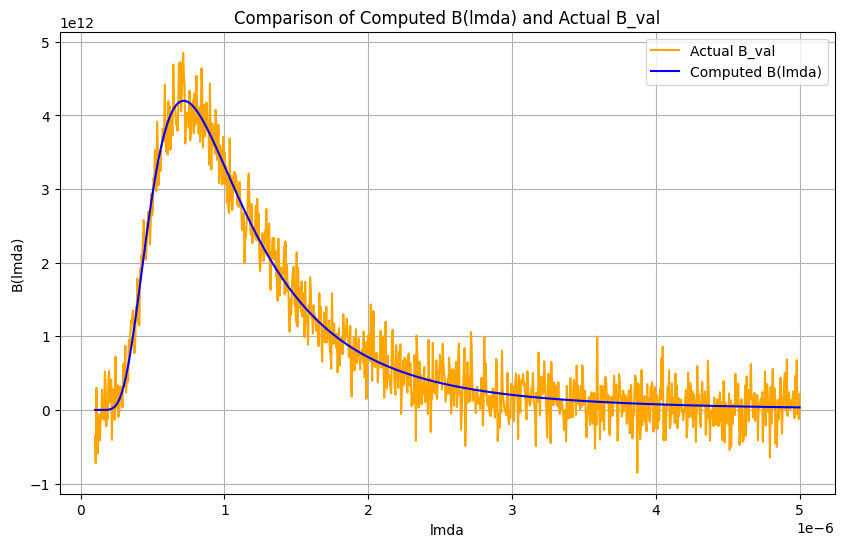



Optimal value of T, when using partial function is  4000.50345877034


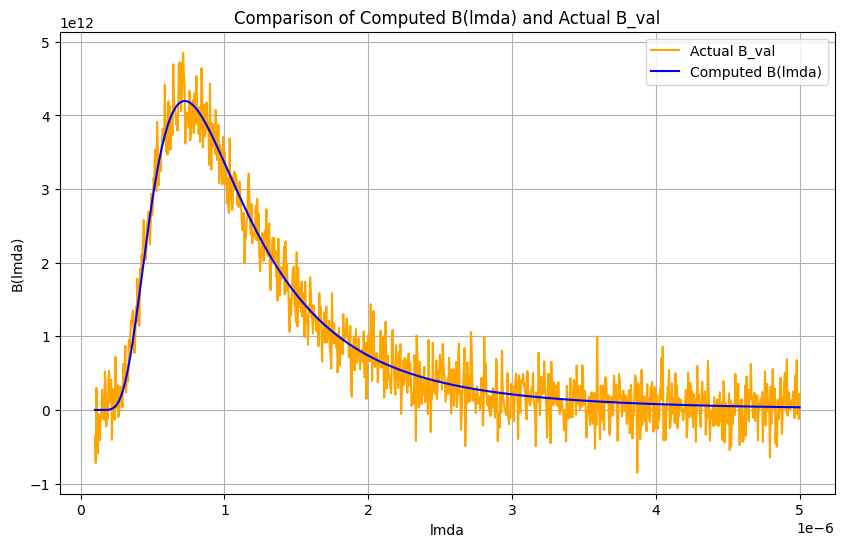



Optimal value of h, when using partial function is  6.623802612903398e-34


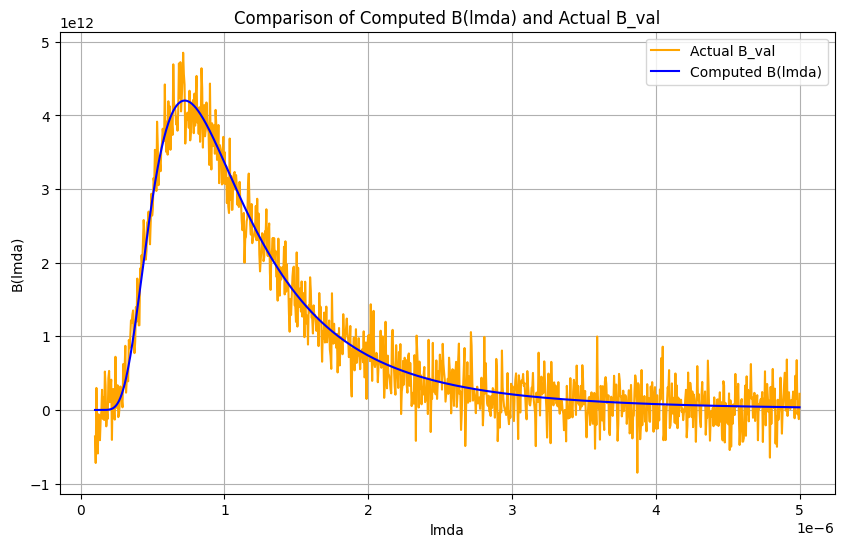



Optimal value of c, when using partial function is  299439504.0734869


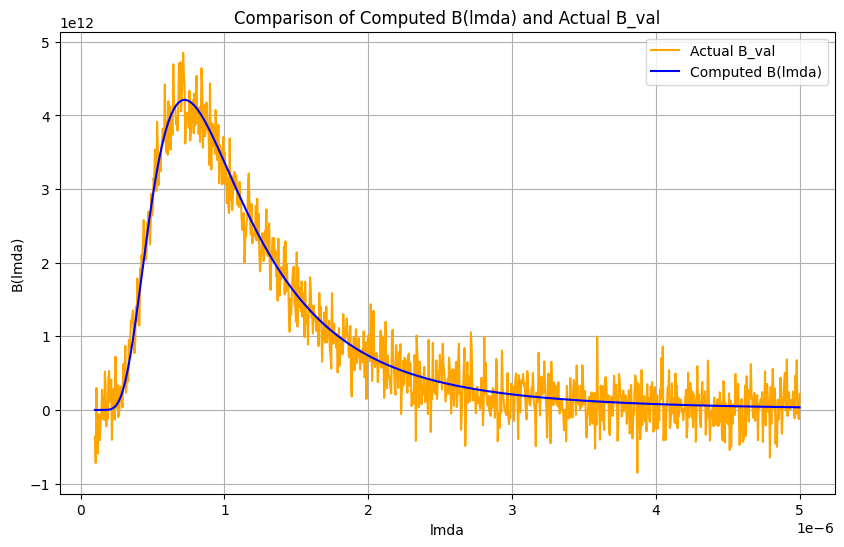



Optimal value of k, when using partial function is  1.3806489840762452e-23


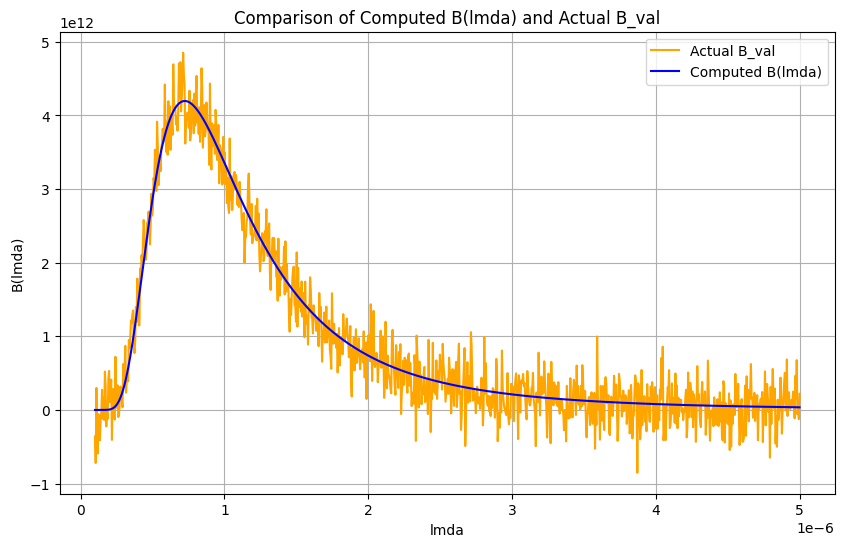

In [ ]:
estimate_all_parameters(lmda, B_val, initial_guess = [6.626e-34, 3e8, 1.38e-23, 3000])
print("\n")
estimating_T(lmda, B_val, initial_guess = 3000)
print("\n")
estimating_h(lmda, B_val, initial_guess = 1e-34)
print("\n")
estimating_c(lmda, B_val, initial_guess = 1e8)
print("\n")
estimating_k(lmda, B_val, initial_guess = 1.38e-23)

## For d4:

In [ ]:
fle  = open("/content/d4.txt")

reader = csv.reader(fle)
lmda = []
B_val = []
for row in reader:
  print(row)
  lmda.append(float(row[0]))
  B_val.append(float(row[1]))

print("The values of t or lmda (wavelength) :", lmda)
print("The corr. values of B are: ",B_val)



['1.0000000000000001e-07', '2333471973505.489']
['1.049049049049049e-07', '2622563569352.3184']
['1.0980980980980982e-07', '-3460210991904.712']
['1.1471471471471473e-07', '2154525608718.1663']
['1.1961961961961964e-07', '2957860583083.32']
['1.2452452452452452e-07', '345818662328.90753']
['1.2942942942942943e-07', '-5025088244834.231']
['1.3433433433433434e-07', '-823339995810.9686']
['1.3923923923923926e-07', '-1290593440006.5947']
['1.4414414414414414e-07', '3506241468864.4883']
['1.4904904904904905e-07', '-56038842461.283844']
['1.5395395395395396e-07', '-8345883660138.57']
['1.5885885885885887e-07', '5230330017371.309']
['1.6376376376376378e-07', '1922464091596.5745']
['1.686686686686687e-07', '-2229467721878.1133']
['1.7357357357357358e-07', '-3127025227752.409']
['1.784784784784785e-07', '4141495534031.3203']
['1.833833833833834e-07', '4135814995017.1777']
['1.882882882882883e-07', '1196310636584.8364']
['1.9319319319319322e-07', '2579148980201.3467']
['1.980980980980981e-07', '

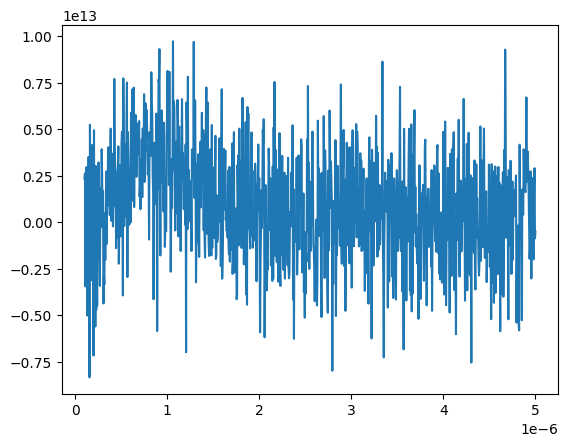

In [ ]:
plt.plot(lmda, B_val)

Optimal values: hopt: 6.22910861486455e-34 , c_opt : 300730721.7989796 ,k_opt: 1.466795058767928e-23 ,T_opt: 3505.2775240901547


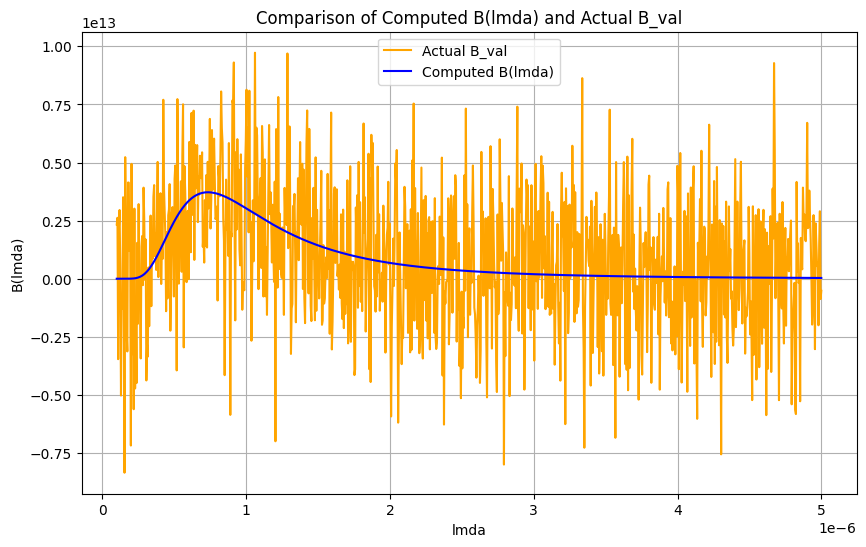



Optimal value of T, when using partial function is  3904.629881019058


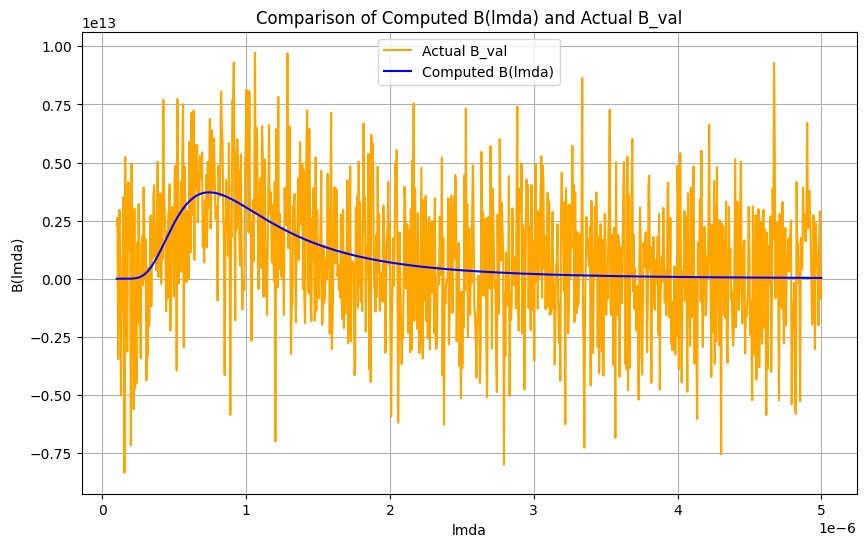



Optimal value of h, when using partial function is  6.623777298794728e-34


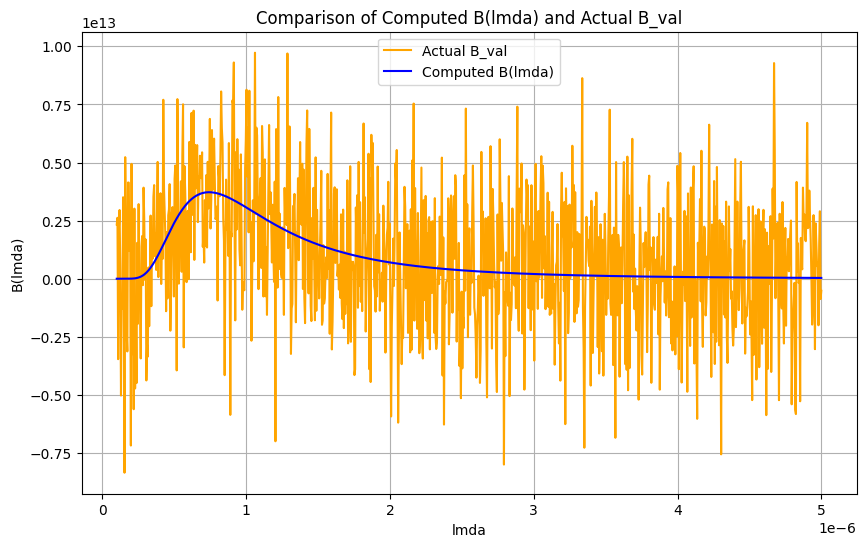



Optimal value of c, when using partial function is  299432748.7329509


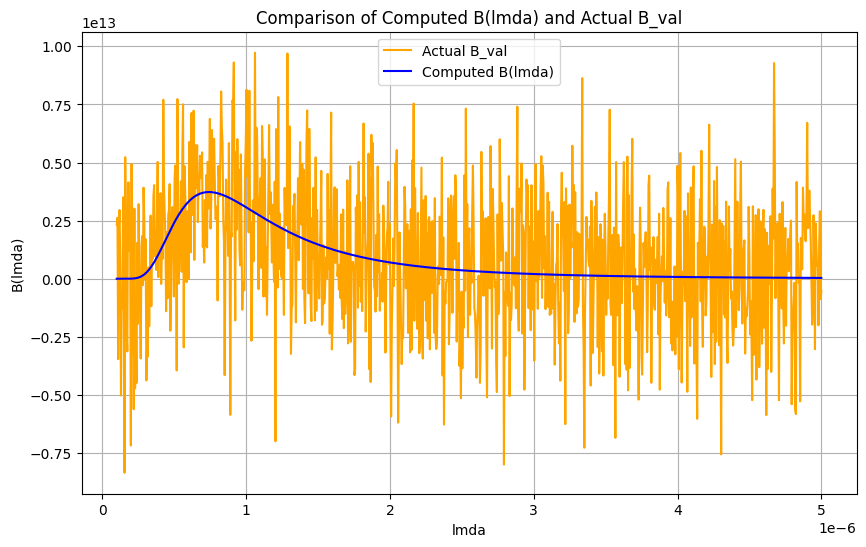



Optimal value of k, when using partial function is  1.380648884137791e-23


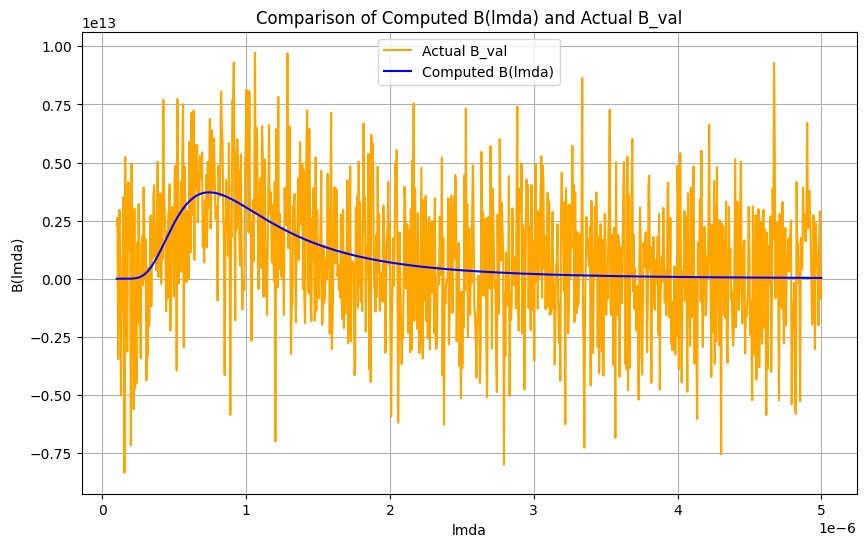

In [ ]:
estimate_all_parameters(lmda, B_val, initial_guess = [6.626e-34, 3e8, 1.38e-23, 3000])
print("\n")
estimating_T(lmda, B_val, initial_guess = 3000)
print("\n")
estimating_h(lmda, B_val, initial_guess = 1e-34)
print("\n")
estimating_c(lmda, B_val, initial_guess = 1e8)
print("\n")
estimating_k(lmda, B_val, initial_guess = 1.38e-23)

                                               ** END OF ASSIGNMENT #3 **